In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [18]:
import librosa
import librosa.display
import numpy as np

def extract_log_mel_spectrogram(audio_path, sr=8000, n_mels=32, hop_length=256, n_fft=512):
    # Загружаем аудио
    y, sr = librosa.load(audio_path, sr=sr)

    # Извлекаем мел-спектрограмму
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

    # Преобразуем в логарифмическую шкалу
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    return log_mel_spec

In [19]:
AUDIO_DIR = "morse_dataset"

filename = train_df.iloc[0]["id"]  # например, "1.opus"
filepath = os.path.join(AUDIO_DIR, filename)

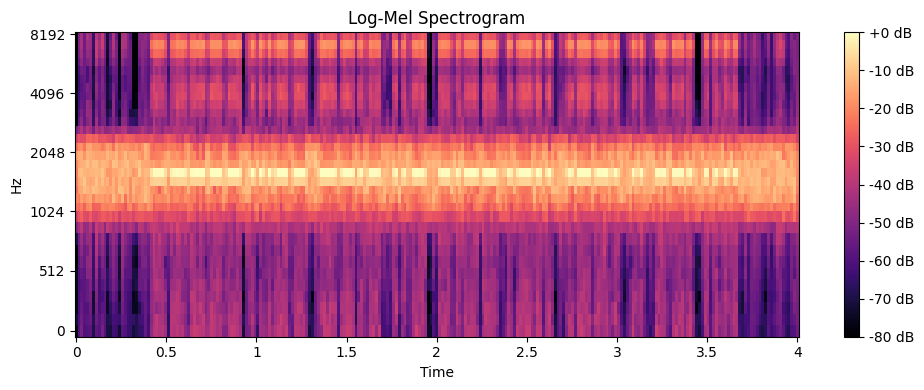

In [20]:
# Пример использования:
audio_file = filepath
features = extract_log_mel_spectrogram(audio_file)

# Визуализация (по желанию)
plt.figure(figsize=(10, 4))
librosa.display.specshow(features, sr=16000, hop_length=256, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [21]:
from torch.utils.data import Dataset
import torch

class MorseDataset(Dataset):
    def __init__(self, dataframe, audio_dir, sr=16000, transform=None):
        self.data = dataframe
        self.audio_dir = audio_dir
        self.sr = sr
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        audio_path = os.path.join(self.audio_dir, row["id"])  # имя файла в csv
        label = row["message"]  # допустим, текстовая расшифровка

        # извлекаем спектрограмму
        spec = extract_log_mel_spectrogram(audio_path, sr=self.sr)

        if self.transform:
            spec = self.transform(spec)

        # Преобразуем в тензор PyTorch
        spec = torch.tensor(spec).float()
        label = str(label)  # оставим как текст пока

        return spec, label

In [37]:
import torch
import torch.nn as nn
import librosa
import numpy as np

class MorseAudioCTCDataset(torch.utils.data.Dataset):
    def __init__(self, paths, targets, sr=16000, transform=None):
        """
        paths: список путей к аудиофайлам
        targets: список списков меток (каждый элемент — список индексов символов)
        sr: частота дискретизации
        transform: функция (signal -> mel_spec), если None, вернём raw
        """
        self.paths = paths
        self.targets = targets
        self.sr = sr
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y, _ = librosa.load(path, sr=self.sr)

        if self.transform:
            mel = self.transform(y)  # [n_mels, time]
        else:
            # Если нет transform, просто заглушка
            mel = torch.tensor(y).unsqueeze(0)  # [1, samples]

        # Превращаем в torch
        mel_tensor = torch.tensor(mel, dtype=torch.float)  # [n_mels, time]

        # label_seq — список int
        label_seq = self.targets[idx]
        label_tensor = torch.tensor(label_seq, dtype=torch.long)  # [seq_len]

        # Длина по временной оси до свёртки/пула
        time_dim = mel_tensor.shape[1]

        return mel_tensor, label_tensor, time_dim


In [22]:
dataset = MorseDataset(dataframe=train_df, audio_dir="morse_dataset")
print("Размер датасета:", len(dataset))

# Проверим 1 пример
spec, label = dataset[29999]
print("📐 Спектрограмма:", spec.shape)
print("🔤 Метка:", label)

Размер датасета: 30000
📐 Спектрограмма: torch.Size([32, 501])
🔤 Метка: ЪЭ8Д2МЗА


In [27]:
all_texts = "".join(train_df["message"].values)  # или train_df
unique_chars = sorted(set("".join(all_texts)))
char2idx = {ch: i+1 for i, ch in enumerate(unique_chars)}
char2idx['<pad>'] = 0

# Обратный словарь
idx2char = {i: ch for ch, i in char2idx.items()}

# Функция кодирования строки
def text_to_indices(text):
    return [char2idx[ch] for ch in text]

In [28]:
char2idx

{' ': 1,
 '#': 2,
 '0': 3,
 '1': 4,
 '2': 5,
 '3': 6,
 '4': 7,
 '5': 8,
 '6': 9,
 '7': 10,
 '8': 11,
 '9': 12,
 'А': 13,
 'Б': 14,
 'В': 15,
 'Г': 16,
 'Д': 17,
 'Е': 18,
 'Ж': 19,
 'З': 20,
 'И': 21,
 'Й': 22,
 'К': 23,
 'Л': 24,
 'М': 25,
 'Н': 26,
 'О': 27,
 'П': 28,
 'Р': 29,
 'С': 30,
 'Т': 31,
 'У': 32,
 'Ф': 33,
 'Х': 34,
 'Ц': 35,
 'Ч': 36,
 'Ш': 37,
 'Щ': 38,
 'Ъ': 39,
 'Ы': 40,
 'Ь': 41,
 'Э': 42,
 'Ю': 43,
 'Я': 44,
 '<pad>': 0}

In [39]:
import torch
import torch.nn as nn

class SimpleCTCModel(nn.Module):
    """
    Упрощённая модель: (Conv + MaxPool2d) -> permute -> 1-layer BiLSTM -> Linear
    """
    def __init__(self, num_classes=30, in_channels=1, n_mels=64, hidden_size=128):
        super(SimpleCTCModel, self).__init__()

        # Conv+Pool: уменьшаем n_mels в 2 и time в 2
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # уменьшение freq и time в 2 раза
        )

        # Предположим, после пула freq = n_mels//2, channels=8 => вход для LSTM = 8*(n_mels//2)
        self.lstm = nn.LSTM(
            input_size=8*(n_mels//2),
            hidden_size=hidden_size,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        self.fc = nn.Linear(hidden_size*2, num_classes)  # bidirectional => *2

    def forward(self, x):
        """
        x: [batch, 1, n_mels, time]
        Выход: [time_out, batch, num_classes]
        """
        # [batch, 8, n_mels//2, time//2]
        x = self.conv(x)

        # Переформатируем: хотим склеить freq и channel => axis=1
        # shape -> [batch, 8*(n_mels//2), time//2]
        b, c, f, t = x.shape
        x = x.view(b, c*f, t)

        # А для LSTM нужен формат (time, batch, features)
        x = x.permute(2, 0, 1)  # => [time//2, batch, 8*(n_mels//2)]

        lstm_out, _ = self.lstm(x)
        # [time//2, batch, hidden_size*2]

        logits = self.fc(lstm_out)
        # [time//2, batch, num_classes]

        return logits



In [30]:
def greedy_decode_ctc(logits, blank=0):
    """
    logits: [time, 1, num_classes] (1 - batch_size)
    Возвращает список индексов (без blank, без повторов подряд)
    """
    argmax = torch.argmax(logits, dim=2)  # [time, 1]
    argmax = argmax.squeeze(1)           # [time]

    decoded = []
    prev = None
    for i in argmax:
        if i != blank and i != prev:
            decoded.append(i.item())
        prev = i.item()
    return decoded


In [38]:
import torch
import torch.nn.functional as F

def ctc_collate_fn(batch, pool_time_factor=2):
    """
    batch: список кортежей (mel_tensor, label_tensor, time_dim)
    pool_time_factor: во сколько раз уменьшается time из-за pooling (если 1 maxpool -> 2)
    Возвращает:
      audio_batch: [batch_size, 1, n_mels, max_time] (zero-padded по time)
      labels_concat: все метки, слитые в один тензор (1D)
      input_lengths: длина time после свёртки/пула
      target_lengths: длина каждой метки
    """
    mel_list = []
    labels_list = []
    target_lengths_list = []
    time_list = []

    # 1) Пробегаем по элементам батча
    for (mel, label, time_dim) in batch:
        # mel.shape: [n_mels, time]
        # label.shape: [seq_len]

        mel_list.append(mel)        # сохраним
        labels_list.append(label)   # сохраним
        target_lengths_list.append(len(label))  # длина метки

        # Это "сырой" time. После пулинга -> time // 2
        out_time = time_dim // pool_time_factor
        time_list.append(out_time)

    # 2) Найдём максимально длинное время
    max_time = max(m.shape[1] for m in mel_list)

    # 3) Паддинг: приводим [n_mels, time] к одной time-длине (max_time)
    # затем добавим dimension=1 (channel) => [1, n_mels, time]
    padded_mels = []
    for mel in mel_list:
        t = mel.shape[1]
        if t < max_time:
            # F.pad(tensor, pad=(left, right, top, bottom))
            # Нам нужен пад справа по оси time, поэтому:
            pad_amount = max_time - t
            mel = F.pad(mel, (0, pad_amount), value=0.0)  # zero-pad
        # теперь shape [n_mels, max_time]
        mel = mel.unsqueeze(0)  # => [1, n_mels, max_time]
        padded_mels.append(mel)

    # 4) Склеиваем в один батч: [batch, 1, n_mels, max_time]
    audio_batch = torch.stack(padded_mels, dim=0)

    # 5) Склеиваем все label'ы
    labels_concat = torch.cat(labels_list, dim=0)  # 1D

    # 6) Превращаем time_list и target_lengths в тензоры
    input_lengths = torch.tensor(time_list, dtype=torch.long)
    target_lengths = torch.tensor(target_lengths_list, dtype=torch.long)

    return audio_batch, labels_concat, input_lengths, target_lengths



In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def train_ctc_loop(model, train_loader, val_loader, num_epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        
        for audio_batch, labels_concat, input_lengths, target_lengths in train_loader:
            # audio_batch: [batch, 1, n_mels, max_time]
            # labels_concat: [sum_of_targets]
            # input_lengths: [batch], длины (time//2)
            # target_lengths: [batch], длины меток
            audio_batch = audio_batch.to(device)
            labels_concat = labels_concat.to(device)
            input_lengths = input_lengths.to(device)
            target_lengths = target_lengths.to(device)
            
            optimizer.zero_grad()
            logits = model(audio_batch)  # [T, B, C], T = max_time//2
            
            log_probs = F.log_softmax(logits, dim=2)
            
            loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        # --- Валидация ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for audio_batch, labels_concat, input_lengths, target_lengths in val_loader:
                audio_batch = audio_batch.to(device)
                labels_concat = labels_concat.to(device)
                input_lengths = input_lengths.to(device)
                target_lengths = target_lengths.to(device)

                logits = model(audio_batch)
                log_probs = F.log_softmax(logits, dim=2)
                loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")


In [34]:
from sklearn.model_selection import train_test_split


train_df = pd.read_csv('train.csv')
    
# делим на обучающую и валидационную выборки
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

train_loader = DataLoader(
        train_df,
        batch_size=8,
        shuffle=True,
        num_workers=2,
        collate_fn=ctc_collate_fn
    )

val_loader = DataLoader(
        val_df,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        collate_fn=ctc_collate_fn
    )
# Модель
model = SimpleCTCModel(num_classes=... , in_channels=1, freq_dim=..., hidden_size=128)

# Тренируем
train_ctc_loop(model, train_loader, val_loader, num_epochs=10, lr=1e-3)

TypeError: unsupported operand type(s) for //: 'ellipsis' and 'int'

In [35]:
train_df = pd.read_csv('train.csv')
train_df

,id,message
0,1.opus,03ЩУЫЛПИГХ
1,2.opus,ЪЛТ0ДС6А3Г
2,3.opus,5ЭКЫБЗХЯН
3,4.opus,ЖЫЦОИ68КФ
4,5.opus,32Ю7МЫ ЗЛ
...,...,...
29995,29996.opus,ЬДТРЭ 9М6М
29996,29997.opus,ЬКТ1 ШЭЪ
29997,29998.opus,ЫВЙЗБЯН7К
29998,29999.opus,ФЯДШ3Т#


In [36]:
char2idx

{' ': 1,
 '#': 2,
 '0': 3,
 '1': 4,
 '2': 5,
 '3': 6,
 '4': 7,
 '5': 8,
 '6': 9,
 '7': 10,
 '8': 11,
 '9': 12,
 'А': 13,
 'Б': 14,
 'В': 15,
 'Г': 16,
 'Д': 17,
 'Е': 18,
 'Ж': 19,
 'З': 20,
 'И': 21,
 'Й': 22,
 'К': 23,
 'Л': 24,
 'М': 25,
 'Н': 26,
 'О': 27,
 'П': 28,
 'Р': 29,
 'С': 30,
 'Т': 31,
 'У': 32,
 'Ф': 33,
 'Х': 34,
 'Ц': 35,
 'Ч': 36,
 'Ш': 37,
 'Щ': 38,
 'Ъ': 39,
 'Ы': 40,
 'Ь': 41,
 'Э': 42,
 'Ю': 43,
 'Я': 44,
 '<pad>': 0}

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from tqdm import tqdm

############################################
# 1) Алфавит (из твоего примера)
############################################
alphabet = {
    '<pad>': 0,
    ' ': 1,
    '#': 2,
    '0': 3,
    '1': 4,
    '2': 5,
    '3': 6,
    '4': 7,
    '5': 8,
    '6': 9,
    '7': 10,
    '8': 11,
    '9': 12,
    'А': 13,
    'Б': 14,
    'В': 15,
    'Г': 16,
    'Д': 17,
    'Е': 18,
    'Ж': 19,
    'З': 20,
    'И': 21,
    'Й': 22,
    'К': 23,
    'Л': 24,
    'М': 25,
    'Н': 26,
    'О': 27,
    'П': 28,
    'Р': 29,
    'С': 30,
    'Т': 31,
    'У': 32,
    'Ф': 33,
    'Х': 34,
    'Ц': 35,
    'Ч': 36,
    'Ш': 37,
    'Щ': 38,
    'Ъ': 39,
    'Ы': 40,
    'Ь': 41,
    'Э': 42,
    'Ю': 43,
    'Я': 44
}

# Число классов = размер словаря (0 = blank/<pad>, и ещё 44 символа).
# В CTCLoss мы будем указывать blank=0
num_classes = len(alphabet)  # 45

############################################
# 2) Функция для кодирования строки в индексы
############################################
def encode_label(text: str, alpha: dict) -> list:
    """
    Превращает строку из символов Морзе (или обычных) в список индексов.
    Предполагается, что все символы text есть в alpha.
    """
    indices = []
    for ch in text:
        if ch in alpha:
            indices.append(alpha[ch])
        else:
            # Если символа нет в словаре, можно пропустить
            # или бросить исключение
            pass
    return indices

############################################
# 3) Функция для Melspectrogram (если нужно)
############################################
def audio_to_melspectrogram(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, 
                                       hop_length=hop_length, n_mels=n_mels)
    log_S = librosa.power_to_db(S, ref=np.max)
    # нормализуем, чтобы сеть училась быстрее
    log_S_norm = (log_S - log_S.min()) / (log_S.max() - log_S.min() + 1e-6)
    return log_S_norm  # [n_mels, time]

############################################
# 4) Dataset для CTC
############################################
class MorseAudioCTCDataset(Dataset):
    def __init__(self, df, sr=16000, transform=audio_to_melspectrogram):
        """
        df: pandas DataFrame c колонками:
           - 'id' (или 'path') - путь к аудио
           - 'label' (строка, которую нужно закодировать)
        sr: частота дискретизации
        transform: функция (signal -> mel)
                   если уже есть готовые npy c mel, адаптируй здесь
        """
        self.df = df.reset_index(drop=True)
        self.sr = sr
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        
        # 1) Загружаем аудио (или готовую Mel, если у тебя уже .npy)
        audio_path = "morse_dataset/" + row['id']  # например: 'data/audio_001.wav'
        y, _ = librosa.load(audio_path, sr=self.sr)

        # 2) Преобразуем в Mel (если нужно)
        if self.transform:
            mel = self.transform(y, sr=self.sr)  # [n_mels, time]
        else:
            mel = y  # raw waveform

        mel_tensor = torch.tensor(mel, dtype=torch.float)  # [n_mels, time]

        # 3) Кодируем label
        text_label = row['message']  # строка
        label_indices = encode_label(text_label, alphabet)  # [ ..., ... ]
        label_tensor = torch.tensor(label_indices, dtype=torch.long)

        # 4) Длина по временной оси
        time_dim = mel_tensor.shape[1]

        return mel_tensor, label_tensor, time_dim

############################################
# 5) Collate_fn для CTC (паддинг по времени)
############################################
def ctc_collate_fn(batch, pool_time_factor=2):
    """
    batch: список (mel_tensor, label_tensor, time_dim)
    pool_time_factor=2 => если модель в итоге уменьшает time в 2 раза
                          (1 MaxPool2d)
    Вернём:
      - audio_batch: [B, 1, n_mels, max_time] (zero-padded)
      - labels_concat: [ all_label_symbols ]
      - input_lengths: [B] длины (time//2)
      - target_lengths: [B]
    """
    mel_list = []
    label_list = []
    target_lengths_list = []
    raw_time_list = []

    # 1) Сбор данных
    for (mel, label, time_dim) in batch:
        mel_list.append(mel)       # [n_mels, time]
        label_list.append(label)   # [seq_len]
        target_lengths_list.append(len(label))
        raw_time_list.append(time_dim)

    # 2) Паддинг спектров
    max_time = max(m.shape[1] for m in mel_list)
    padded_mels = []
    for mel in mel_list:
        t = mel.shape[1]
        if t < max_time:
            pad_amount = max_time - t
            # pad=(left, right, top, bottom) => мы паддим справа по оси time
            mel = F.pad(mel, (0, pad_amount), value=0.0)
        # mel => [n_mels, max_time]
        mel = mel.unsqueeze(0)  # => [1, n_mels, max_time] = channel first
        padded_mels.append(mel)

    # теперь stack => [B, 1, n_mels, max_time]
    audio_batch = torch.stack(padded_mels, dim=0)

    # 3) Склеиваем все label'ы
    labels_concat = torch.cat(label_list, dim=0)

    # 4) input_lengths = raw_time_list // 2
    #   если у тебя 1 MaxPool2d(kernel_size=(2,2)), time будет сокращаться в 2 раза
    input_lengths = []
    for tdim in raw_time_list:
        input_lengths.append(tdim // pool_time_factor)

    input_lengths = torch.tensor(input_lengths, dtype=torch.long)
    target_lengths = torch.tensor(target_lengths_list, dtype=torch.long)

    return audio_batch, labels_concat, input_lengths, target_lengths

############################################
# 6) Модель (1 Conv+Pool + 1 BiLSTM)
############################################
class SimpleCTCModel(nn.Module):
    def __init__(self, num_classes, in_channels=1, n_mels=64, hidden_size=128):
        """
        num_classes: размер алфавита (включая blank=0)
        """
        super(SimpleCTCModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # уменьшит freq и time в 2 раза
        )

        # после пула freq -> n_mels//2, channels -> 8 => вход в LSTM = 8*(n_mels//2)
        self.lstm = nn.LSTM(
            input_size=8*(n_mels//2),
            hidden_size=hidden_size,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        """
        x: [B, 1, n_mels, time]
        Выдаём: [time//2, B, num_classes]
        """
        x = self.conv(x)
        # x => [B, 8, n_mels//2, time//2]

        b, c, f, t = x.shape
        # Склеим (channels * freq) в одну ось => [B, c*f, t]
        x = x.view(b, c*f, t)

        # Для LSTM нужен формат [time, batch, features]
        x = x.permute(2, 0, 1)  # => [t, B, c*f]

        lstm_out, _ = self.lstm(x)
        # => [t, B, hidden_size*2]
        logits = self.fc(lstm_out)
        # => [t, B, num_classes]

        return logits

############################################
# 7) Цикл обучения с CTC Loss + tqdm
############################################
def train_ctc_loop(model, train_loader, val_loader, num_epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    # blank=0 => соответствует '<pad>' из alphabet

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # ---------- TRAINING ----------
        model.train()
        train_loss_sum = 0.0
        train_bar = tqdm(train_loader, desc="Train", leave=False)

        for audio_batch, labels_concat, input_lengths, target_lengths in train_bar:
            audio_batch = audio_batch.to(device)        # [B, 1, n_mels, max_time]
            labels_concat = labels_concat.to(device)    # [sum_of_targets]
            input_lengths = input_lengths.to(device)    # [B]
            target_lengths = target_lengths.to(device)  # [B]

            optimizer.zero_grad()
            logits = model(audio_batch)          # [T, B, C]
            log_probs = F.log_softmax(logits, 2) # [T, B, C]
            
            loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = train_loss_sum / len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        val_loss_sum = 0.0
        val_bar = tqdm(val_loader, desc="Val", leave=False)

        with torch.no_grad():
            for audio_batch, labels_concat, input_lengths, target_lengths in val_bar:
                audio_batch = audio_batch.to(device)
                labels_concat = labels_concat.to(device)
                input_lengths = input_lengths.to(device)
                target_lengths = target_lengths.to(device)

                logits = model(audio_batch)   
                log_probs = F.log_softmax(logits, dim=2)
                
                loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
                val_loss_sum += loss.item()
                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = val_loss_sum / len(val_loader)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}")

############################################
# 8) Пример main
############################################
if __name__ == "__main__":
    # Допустим, в train.csv есть колонки ['id', 'label']
    # где 'id' = путь к аудио (напр. "data/001.wav"), 'label' = строка (напр. "ПРИВЕТ")
    df = pd.read_csv("train.csv")  # свои пути к csv
    
    # Делим на train/val
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    # Создаём датасеты
    train_dataset = MorseAudioCTCDataset(train_df, sr=16000, transform=audio_to_melspectrogram)
    val_dataset   = MorseAudioCTCDataset(val_df,   sr=16000, transform=audio_to_melspectrogram)

    # Даталоадеры
    # Здесь pool_time_factor=2, потому что в модели один MaxPool2d(2,2)
    train_loader = DataLoader(
        train_dataset,
        batch_size=4,
        shuffle=True,
        num_workers=0,  # Windows/Jupyter => 0 (иначе могут быть проблемы)
        collate_fn=lambda b: ctc_collate_fn(b, pool_time_factor=2)
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        collate_fn=lambda b: ctc_collate_fn(b, pool_time_factor=2)
    )

    # Модель
    #  n_mels=64 (см. audio_to_melspectrogram),
    #  num_classes = 45 (у нас 45, т.к. 0..44)
    model = SimpleCTCModel(num_classes=num_classes, in_channels=1, n_mels=64, hidden_size=128)
    
    audio_batch, labels_concat, input_lengths, target_lengths = next(iter(train_loader))

    # Проверим размеры:
    print("audio_batch shape:", audio_batch.shape)         # [B, 1, n_mels, max_time]
    print("labels_concat shape:", labels_concat.shape)     # [sum_of_labels]
    print("input_lengths:", input_lengths)
    print("target_lengths:", target_lengths)
    
    print("Labels in this batch:", labels_concat)
    # print("logits shape:", logits.shape)
    # logits.shape[0] = T
    print("sum of target lengths:", target_lengths.sum().item())

    
    # Прогоняем через модель
    model.eval()
    with torch.no_grad():
        logits = model(audio_batch)           # [T, B, num_classes]
        log_probs = F.log_softmax(logits, 2)  # CTC требует log_softmax по последней оси
    
        ctc = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
        test_loss = ctc(log_probs, labels_concat, input_lengths, target_lengths)
    
    print("CTC test loss:", test_loss.item())

    # Запускаем обучение
    train_ctc_loop(model, train_loader, val_loader, num_epochs=10, lr=1e-3)

audio_batch shape: torch.Size([4, 1, 64, 251])
labels_concat shape: torch.Size([34])
input_lengths: tensor([125, 125, 125, 125])
target_lengths: tensor([ 7,  9,  8, 10])
Labels in this batch: tensor([ 8, 14, 15,  4, 37,  8,  7, 33, 13,  3,  5, 36, 10,  1, 13,  4, 15,  1,
        19, 41, 38,  5, 38,  9, 40, 14, 29,  1, 27, 25,  2, 22,  1, 25])
sum of target lengths: 34
CTC test loss: 51.145477294921875

Epoch 1/10


KeyboardInterrupt: 

In [4]:
# Допустим, модель уже обучена в текущем скрипте
torch.save(model.state_dict(), "my_morse_ctc.pth")

In [ ]:
# Создаём модель с точно такой же архитектурой
model = SimpleCTCModel(num_classes=..., in_channels=..., n_mels=..., hidden_size=...)

# Загружаем веса
state_dict = torch.load("my_morse_ctc.pth", map_location="cpu")
model.load_state_dict(state_dict)

# Теперь model содержит обученные веса
model.eval()  # для инференса


In [2]:
############################################
# 9) Инференс (eval) на test.csv
############################################

# 9.1 Обратный словарь, чтобы индексы -> символ
idx2char = {v: k for k, v in alphabet.items()}

def greedy_decode_ctc(log_probs, blank=0):
    """
    log_probs: [T, 1, C] – выход после log_softmax (или logits -> argmax)
    Возвращаем список индексов без подряд идущих дублей и без blank.
    """
    # Находим argmax по последней оси (C)
    argmax = torch.argmax(log_probs, dim=2)  # [T, 1]
    argmax = argmax.squeeze(1)               # [T]
    argmax = argmax.cpu().numpy().tolist()

    decoded = []
    prev = None
    for idx in argmax:
        if idx != blank and idx != prev:
            decoded.append(idx)
        prev = idx
    return decoded

def infer_on_test(model, test_csv, output_csv="submission.csv", audio_dir="morse_dataset", sr=16000):
    """
    model: твоя обученная модель (SimpleCTCModel)
    test_csv: путь к test.csv, где есть колонка 'id' (путь к аудио)
    output_csv: куда сохранить результат (CSV)
    audio_dir: папка с аудио, если надо что-то добавить к пути
    sr: частота дискретизации
    """
    import os
    
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    test_df = pd.read_csv(test_csv)
    results = []

    with torch.no_grad():
        for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Inference"):
            file_id = row['id']  # допустим, "001.wav"
            audio_path = os.path.join(audio_dir, file_id)

            # 1) Загружаем аудио
            y, _ = librosa.load(audio_path, sr=sr)
            # 2) Превращаем в Mel-спектр (как при обучении)
            mel = audio_to_melspectrogram(y, sr=sr)  # [n_mels, time]
            mel_tensor = torch.tensor(mel, dtype=torch.float)
            # [1, n_mels, time] => добавляем размер под channel=1 => [1, 1, n_mels, time]
            mel_tensor = mel_tensor.unsqueeze(0).unsqueeze(0).to(device)

            # 3) Прогоняем через модель
            logits = model(mel_tensor)           # [T, 1, num_classes]
            log_probs = F.log_softmax(logits, 2) # [T, 1, num_classes]

            # 4) Декодируем (CTC greedy)
            pred_indices = greedy_decode_ctc(log_probs, blank=0)

            # 5) Превращаем индексы -> символы
            pred_symbols = [idx2char[i] for i in pred_indices if i in idx2char]
            pred_text = ''.join(pred_symbols)

            # Сохраняем результат
            results.append({
                "id": file_id,
                "message": pred_text
            })

    # Запишем в CSV
    result_df = pd.DataFrame(results)
    result_df.to_csv(output_csv, index=False)
    print(f"✅ Результат сохранён в {output_csv}")


In [3]:
if __name__ == "__main__":
    # ... после обучения модели ...
    # допустим, модель сохранена
    # torch.save(model.state_dict(), "my_morse_ctc.pth")
    
    # Чтобы загрузить
    # model = SimpleCTCModel(num_classes, ...)
    # model.load_state_dict(torch.load("my_morse_ctc.pth"))

    # Теперь делаем инференс
    infer_on_test(
        model=model,
        test_csv="test.csv",        # содержит колонку 'id'
        output_csv="submission.csv",
        audio_dir="morse_dataset",  # папка с файлами
        sr=16000
    )


Inference: 100%|██████████| 5000/5000 [02:05<00:00, 39.73it/s]

✅ Результат сохранён в submission.csv


In [5]:
sub = pd.read_csv("submission.csv")
sub

,id,message
0,30001.opus,ЯЮ6ЛИТЖБШ
1,30002.opus,КЩ В9Ю 9
2,30003.opus,Ы65Ф61Я
3,30004.opus,ЖЖНЖ9РЫНЦ3
4,30005.opus,ЯУ4ЮЧЬ
...,...,...
4995,34996.opus,Р3Р4АЬУУА
4996,34997.opus,Х РЯ
4997,34998.opus,ЕРЛХ6ХРАЛЬАИФЭ54А
4998,34999.opus,4Х4 7 3АЯ УЮ ЭЛЮАП ФРЦЛС Ю


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EnhancedCTCModel(nn.Module):
    """
    Расширенная модель для CTC:
     - Два Conv-блока (каждый: Conv2D -> BN -> ReLU -> MaxPool2d)
     - 2-слойная BiLSTM (c dropout)
     - Linear выход
    Выходная форма такая же: [time, batch, num_classes]
    """
    def __init__(self, num_classes=30, in_channels=1, n_mels=64,
                 hidden_size=128, lstm_layers=2, dropout=0.3):
        super(EnhancedCTCModel, self).__init__()

        # ---- 1) Конвольные блоки ----
        # Первый блок: уменьшит freq/time в 2 раза
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # freq, time => // 2
        )
        # Второй блок: уменьшит freq/time ещё в 2 раза => итого //4
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # freq, time => //2 ещё раз
        )

        # Итого после 2 блоков: частота = n_mels//4, каналы = 32

        # ---- 2) BiLSTM ----
        # Вход в LSTM: 32 * (n_mels//4)
        self.lstm = nn.LSTM(
            input_size=32 * (n_mels // 4),
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            dropout=(dropout if lstm_layers > 1 else 0.0),  # dropout в LSTM применяется между слоями
            bidirectional=True,
            batch_first=False
        )

        # ---- 3) Выход ----
        # bidirectional => hidden_size*2
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        """
        x: [batch, in_channels=1, n_mels=64, time]
        Возвращаем: [time_out, batch, num_classes]
        """
        # --- Conv1 ---
        x = self.conv1(x)  # [B, 16, n_mels//2, time//2]
        # --- Conv2 ---
        x = self.conv2(x)  # [B, 32, n_mels//4, time//4]

        b, c, f, t = x.shape  # channel=32, freq=(n_mels//4), time=(time_in//4)

        # Склеиваем channel и freq => feature dim
        x = x.view(b, c*f, t)  # [B, 32*(n_mels//4), time//4]

        # LSTM требует [time, batch, feature]
        x = x.permute(2, 0, 1)  # => [time//4, B, 32*(n_mels//4)]

        # Пропускаем через LSTM
        lstm_out, _ = self.lstm(x)
        # => [time//4, B, hidden_size*2]

        # Финальный линейный слой
        logits = self.fc(lstm_out)  
        # => [time//4, B, num_classes]

        return logits


In [1]:
import torch.nn.functional as F

def beam_search_ctc(logits, blank=0, beam_width=5):
    """
    logits: [T, 1, C] (1 sample), например после модели
    Возвращает: список индексов (лучшая гипотеза)
    """
    # Превращаем logits -> log_probs
    log_probs = F.log_softmax(logits, dim=2)  # [T, 1, C]
    # Снимем batch=1
    log_probs = log_probs.squeeze(1)          # [T, C]

    # ... Тут реализуем beam search c прунингом ...
    # Можно использовать готовые библиотеки (например "ctcdecode" или "torch.nn.CTCLoss"), 
    # но в PyTorch нет встроенной beam search. 
    # Простейший вариант можно найти в интернете (например https://github.com/parlance/ctcdecode)
    # или написать самодельно. Ниже - упрощённый псевдокод:

    T, C = log_probs.shape
    # beam - список (prefix, score, last_symbol)
    beam = [([], 0.0, None)]  # пустое начало, логскор=0.0

    for t in range(T):
        new_beam = []
        for prefix, score, last_sym in beam:
            # расширяем beam всеми возможными символами
            for c_idx in range(C):
                p = log_probs[t, c_idx].item()  # логвероятность
                new_score = score + p
                if c_idx == blank:
                    # Если blank, остаёмся при префиксе без добавления
                    new_beam.append((prefix, new_score, None))
                else:
                    # Если тот же символ, что и раньше, пропускаем повтор
                    if c_idx == last_sym:
                        new_beam.append((prefix, new_score, c_idx))
                    else:
                        new_prefix = prefix + [c_idx]
                        new_beam.append((new_prefix, new_score, c_idx))
        # Сортируем по new_score и оставляем top beam_width
        new_beam = sorted(new_beam, key=lambda x: x[1], reverse=True)[:beam_width]
        beam = new_beam

    # Лучший путь - нулевой элемент
    best_prefix, best_score, _ = beam[0]
    return best_prefix



In [9]:
def ctc_collate_fn(batch, pool_time_factor=4):
    """
    batch: список (mel_tensor, label_tensor, time_dim)
    pool_time_factor=2 => если модель в итоге уменьшает time в 2 раза
                          (1 MaxPool2d)
    Вернём:
      - audio_batch: [B, 1, n_mels, max_time] (zero-padded)
      - labels_concat: [ all_label_symbols ]
      - input_lengths: [B] длины (time//2)
      - target_lengths: [B]
    """
    mel_list = []
    label_list = []
    target_lengths_list = []
    raw_time_list = []

    # 1) Сбор данных
    for (mel, label, time_dim) in batch:
        mel_list.append(mel)       # [n_mels, time]
        label_list.append(label)   # [seq_len]
        target_lengths_list.append(len(label))
        raw_time_list.append(time_dim)

    # 2) Паддинг спектров
    max_time = max(m.shape[1] for m in mel_list)
    padded_mels = []
    for mel in mel_list:
        t = mel.shape[1]
        if t < max_time:
            pad_amount = max_time - t
            # pad=(left, right, top, bottom) => мы паддим справа по оси time
            mel = F.pad(mel, (0, pad_amount), value=0.0)
        # mel => [n_mels, max_time]
        mel = mel.unsqueeze(0)  # => [1, n_mels, max_time] = channel first
        padded_mels.append(mel)

    # теперь stack => [B, 1, n_mels, max_time]
    audio_batch = torch.stack(padded_mels, dim=0)

    # 3) Склеиваем все label'ы
    labels_concat = torch.cat(label_list, dim=0)

    # 4) input_lengths = raw_time_list // 2
    #   если у тебя 1 MaxPool2d(kernel_size=(2,2)), time будет сокращаться в 2 раза
    input_lengths = []
    for tdim in raw_time_list:
        input_lengths.append(tdim // pool_time_factor)

    input_lengths = torch.tensor(input_lengths, dtype=torch.long)
    target_lengths = torch.tensor(target_lengths_list, dtype=torch.long)

    return audio_batch, labels_concat, input_lengths, target_lengths

In [ ]:
model = EnhancedCTCModel(
    num_classes=45,
    in_channels=1,
    n_mels=64,
    hidden_size=256,
    lstm_layers=2,
    dropout=0.3
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda b: ctc_collate_fn(b, pool_time_factor=4)
)

# Меняем LR
train_ctc_loop(model, train_loader, val_loader, num_epochs=15, lr=1e-4)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from tqdm import tqdm

############################################
# 1) Алфавит (из твоего примера)
############################################
alphabet = {
    '<pad>': 0,
    ' ': 1,
    '#': 2,
    '0': 3,
    '1': 4,
    '2': 5,
    '3': 6,
    '4': 7,
    '5': 8,
    '6': 9,
    '7': 10,
    '8': 11,
    '9': 12,
    'А': 13,
    'Б': 14,
    'В': 15,
    'Г': 16,
    'Д': 17,
    'Е': 18,
    'Ж': 19,
    'З': 20,
    'И': 21,
    'Й': 22,
    'К': 23,
    'Л': 24,
    'М': 25,
    'Н': 26,
    'О': 27,
    'П': 28,
    'Р': 29,
    'С': 30,
    'Т': 31,
    'У': 32,
    'Ф': 33,
    'Х': 34,
    'Ц': 35,
    'Ч': 36,
    'Ш': 37,
    'Щ': 38,
    'Ъ': 39,
    'Ы': 40,
    'Ь': 41,
    'Э': 42,
    'Ю': 43,
    'Я': 44
}

# Число классов = размер словаря (0 = blank/<pad>, и ещё 44 символа).
# В CTCLoss мы будем указывать blank=0
num_classes = len(alphabet)  # 45

############################################
# 2) Функция для кодирования строки в индексы
############################################
def encode_label(text: str, alpha: dict) -> list:
    """
    Превращает строку из символов Морзе (или обычных) в список индексов.
    Предполагается, что все символы text есть в alpha.
    """
    indices = []
    for ch in text:
        if ch in alpha:
            indices.append(alpha[ch])
        else:
            # Если символа нет в словаре, можно пропустить
            # или бросить исключение
            pass
    return indices

############################################
# 3) Функция для Melspectrogram (если нужно)
############################################
def audio_to_melspectrogram(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, 
                                       hop_length=hop_length, n_mels=n_mels)
    log_S = librosa.power_to_db(S, ref=np.max)
    # нормализуем, чтобы сеть училась быстрее
    log_S_norm = (log_S - log_S.min()) / (log_S.max() - log_S.min() + 1e-6)
    return log_S_norm  # [n_mels, time]

############################################
# 4) Dataset для CTC
############################################
class MorseAudioCTCDataset(Dataset):
    def __init__(self, df, sr=16000, transform=audio_to_melspectrogram):
        """
        df: pandas DataFrame c колонками:
           - 'id' (или 'path') - путь к аудио
           - 'label' (строка, которую нужно закодировать)
        sr: частота дискретизации
        transform: функция (signal -> mel)
                   если уже есть готовые npy c mel, адаптируй здесь
        """
        self.df = df.reset_index(drop=True)
        self.sr = sr
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        
        # 1) Загружаем аудио (или готовую Mel, если у тебя уже .npy)
        audio_path = "morse_dataset/" + row['id']  # например: 'data/audio_001.wav'
        y, _ = librosa.load(audio_path, sr=self.sr)

        # 2) Преобразуем в Mel (если нужно)
        if self.transform:
            mel = self.transform(y, sr=self.sr)  # [n_mels, time]
        else:
            mel = y  # raw waveform

        mel_tensor = torch.tensor(mel, dtype=torch.float)  # [n_mels, time]

        # 3) Кодируем label
        text_label = row['message']  # строка
        label_indices = encode_label(text_label, alphabet)  # [ ..., ... ]
        label_tensor = torch.tensor(label_indices, dtype=torch.long)

        # 4) Длина по временной оси
        time_dim = mel_tensor.shape[1]

        return mel_tensor, label_tensor, time_dim

############################################
# 5) Collate_fn для CTC (паддинг по времени)
############################################
def ctc_collate_fn(batch, pool_time_factor=4):
    """
    batch: список (mel_tensor, label_tensor, time_dim)
    pool_time_factor=2 => если модель в итоге уменьшает time в 2 раза
                          (1 MaxPool2d)
    Вернём:
      - audio_batch: [B, 1, n_mels, max_time] (zero-padded)
      - labels_concat: [ all_label_symbols ]
      - input_lengths: [B] длины (time//2)
      - target_lengths: [B]
    """
    mel_list = []
    label_list = []
    target_lengths_list = []
    raw_time_list = []

    # 1) Сбор данных
    for (mel, label, time_dim) in batch:
        mel_list.append(mel)       # [n_mels, time]
        label_list.append(label)   # [seq_len]
        target_lengths_list.append(len(label))
        raw_time_list.append(time_dim)

    # 2) Паддинг спектров
    max_time = max(m.shape[1] for m in mel_list)
    padded_mels = []
    for mel in mel_list:
        t = mel.shape[1]
        if t < max_time:
            pad_amount = max_time - t
            # pad=(left, right, top, bottom) => мы паддим справа по оси time
            mel = F.pad(mel, (0, pad_amount), value=0.0)
        # mel => [n_mels, max_time]
        mel = mel.unsqueeze(0)  # => [1, n_mels, max_time] = channel first
        padded_mels.append(mel)

    # теперь stack => [B, 1, n_mels, max_time]
    audio_batch = torch.stack(padded_mels, dim=0)

    # 3) Склеиваем все label'ы
    labels_concat = torch.cat(label_list, dim=0)

    # 4) input_lengths = raw_time_list // 2
    #   если у тебя 1 MaxPool2d(kernel_size=(2,2)), time будет сокращаться в 2 раза
    input_lengths = []
    for tdim in raw_time_list:
        input_lengths.append(tdim // pool_time_factor)

    input_lengths = torch.tensor(input_lengths, dtype=torch.long)
    target_lengths = torch.tensor(target_lengths_list, dtype=torch.long)

    return audio_batch, labels_concat, input_lengths, target_lengths

############################################
# 6) Модель (1 Conv+Pool + 1 BiLSTM)
############################################
class EnhancedCTCModel(nn.Module):
    """
    Расширенная модель для CTC:
     - Два Conv-блока (каждый: Conv2D -> BN -> ReLU -> MaxPool2d)
     - 2-слойная BiLSTM (c dropout)
     - Linear выход
    Выходная форма такая же: [time, batch, num_classes]
    """
    def __init__(self, num_classes=30, in_channels=1, n_mels=64,
                 hidden_size=128, lstm_layers=2, dropout=0.3):
        super(EnhancedCTCModel, self).__init__()

        # ---- 1) Конвольные блоки ----
        # Первый блок: уменьшит freq/time в 2 раза
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # freq, time => // 2
        )
        # Второй блок: уменьшит freq/time ещё в 2 раза => итого //4
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2))  # freq, time => //2 ещё раз
        )

        # Итого после 2 блоков: частота = n_mels//4, каналы = 32

        # ---- 2) BiLSTM ----
        # Вход в LSTM: 32 * (n_mels//4)
        self.lstm = nn.LSTM(
            input_size=32 * (n_mels // 4),
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            dropout=(dropout if lstm_layers > 1 else 0.0),  # dropout в LSTM применяется между слоями
            bidirectional=True,
            batch_first=False
        )

        # ---- 3) Выход ----
        # bidirectional => hidden_size*2
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        """
        x: [batch, in_channels=1, n_mels=64, time]
        Возвращаем: [time_out, batch, num_classes]
        """
        # --- Conv1 ---
        x = self.conv1(x)  # [B, 16, n_mels//2, time//2]
        # --- Conv2 ---
        x = self.conv2(x)  # [B, 32, n_mels//4, time//4]

        b, c, f, t = x.shape  # channel=32, freq=(n_mels//4), time=(time_in//4)

        # Склеиваем channel и freq => feature dim
        x = x.view(b, c*f, t)  # [B, 32*(n_mels//4), time//4]

        # LSTM требует [time, batch, feature]
        x = x.permute(2, 0, 1)  # => [time//4, B, 32*(n_mels//4)]

        # Пропускаем через LSTM
        lstm_out, _ = self.lstm(x)
        # => [time//4, B, hidden_size*2]

        # Финальный линейный слой
        logits = self.fc(lstm_out)  
        # => [time//4, B, num_classes]

        return logits

############################################
# 7) Цикл обучения с CTC Loss + tqdm
############################################
def train_ctc_loop(model, train_loader, val_loader, num_epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    # blank=0 => соответствует '<pad>' из alphabet

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        # ---------- TRAINING ----------
        model.train()
        train_loss_sum = 0.0
        train_bar = tqdm(train_loader, desc="Train", leave=False)

        for audio_batch, labels_concat, input_lengths, target_lengths in train_bar:
            audio_batch = audio_batch.to(device)        # [B, 1, n_mels, max_time]
            labels_concat = labels_concat.to(device)    # [sum_of_targets]
            input_lengths = input_lengths.to(device)    # [B]
            target_lengths = target_lengths.to(device)  # [B]

            optimizer.zero_grad()
            logits = model(audio_batch)          # [T, B, C]
            log_probs = F.log_softmax(logits, 2) # [T, B, C]
            
            loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = train_loss_sum / len(train_loader)

        # ---------- VALIDATION ----------
        model.eval()
        val_loss_sum = 0.0
        val_bar = tqdm(val_loader, desc="Val", leave=False)

        with torch.no_grad():
            for audio_batch, labels_concat, input_lengths, target_lengths in val_bar:
                audio_batch = audio_batch.to(device)
                labels_concat = labels_concat.to(device)
                input_lengths = input_lengths.to(device)
                target_lengths = target_lengths.to(device)

                logits = model(audio_batch)   
                log_probs = F.log_softmax(logits, dim=2)
                
                loss = ctc_loss(log_probs, labels_concat, input_lengths, target_lengths)
                val_loss_sum += loss.item()
                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = val_loss_sum / len(val_loader)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}")

############################################
# 8) Пример main
############################################
if __name__ == "__main__":
    # Допустим, в train.csv есть колонки ['id', 'label']
    # где 'id' = путь к аудио (напр. "data/001.wav"), 'label' = строка (напр. "ПРИВЕТ")
    df = pd.read_csv("train.csv")  # свои пути к csv
    
    # Делим на train/val
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    # Создаём датасеты
    train_dataset = MorseAudioCTCDataset(train_df, sr=16000, transform=audio_to_melspectrogram)
    val_dataset   = MorseAudioCTCDataset(val_df,   sr=16000, transform=audio_to_melspectrogram)

    # Даталоадеры
    train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda b: ctc_collate_fn(b, pool_time_factor=4)
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        collate_fn=lambda b: ctc_collate_fn(b, pool_time_factor=4)
    )

    # Модель
    model = EnhancedCTCModel(
    num_classes=45,
    in_channels=1,
    n_mels=64,
    hidden_size=256,
    lstm_layers=2,
    dropout=0.3
    )
    
    audio_batch, labels_concat, input_lengths, target_lengths = next(iter(train_loader))

    # Проверим размеры:
    print("audio_batch shape:", audio_batch.shape)         # [B, 1, n_mels, max_time]
    print("labels_concat shape:", labels_concat.shape)     # [sum_of_labels]
    print("input_lengths:", input_lengths)
    print("target_lengths:", target_lengths)
    
    print("Labels in this batch:", labels_concat)
    # print("logits shape:", logits.shape)
    # logits.shape[0] = T
    print("sum of target lengths:", target_lengths.sum().item())

    
    # Прогоняем через модель
    model.eval()
    with torch.no_grad():
        logits = model(audio_batch)           # [T, B, num_classes]
        log_probs = F.log_softmax(logits, 2)  # CTC требует log_softmax по последней оси
    
        ctc = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
        test_loss = ctc(log_probs, labels_concat, input_lengths, target_lengths)
    
    print("CTC test loss:", test_loss.item())

    # Запускаем обучение
    train_ctc_loop(model, train_loader, val_loader, num_epochs=15, lr=1e-3)

audio_batch shape: torch.Size([4, 1, 64, 251])
labels_concat shape: torch.Size([43])
input_lengths: tensor([62, 62, 62, 62])
target_lengths: tensor([14,  8, 11, 10])
Labels in this batch: tensor([16, 33, 13, 38, 41, 21, 30,  1, 21,  1, 41,  8, 28, 23, 15, 33, 28, 33,
        43, 28,  1, 21, 13, 30,  9, 27, 37, 11, 18, 26, 16, 16,  7,  5, 36, 17,
         8,  8, 43, 32, 42, 44, 22])
sum of target lengths: 43
CTC test loss: 18.957365036010742

Epoch 1/15


Epoch 1/15 | Train Loss: 4.0134 | Val Loss: 3.9923

Epoch 2/15


Epoch 2/15 | Train Loss: 3.9847 | Val Loss: 3.9790

Epoch 3/15


Epoch 3/15 | Train Loss: 3.9788 | Val Loss: 3.9713

Epoch 4/15


Epoch 4/15 | Train Loss: 3.9557 | Val Loss: 3.8928

Epoch 5/15


...

Epoch 11/15 | Train Loss: 0.2421 | Val Loss: 0.2924

Epoch 12/15


Epoch 12/15 | Train Loss: 0.2214 | Val Loss: 0.2965

Epoch 13/15


Epoch 13/15 | Train Loss: 0.2034 | Val Loss: 0.3117

Epoch 14/15


Epoch 14/15 | Train Loss: 0.1886 | Val Loss: 0.2880

Epoch 15/15


Epoch 15/15 | Train Loss: 0.1741 | Val Loss: 0.3052


In [5]:
# Допустим, модель уже обучена в текущем скрипте
torch.save(model.state_dict(), "EnhancedCTCModel.pth")

In [6]:
import torch
import torch.nn.functional as F
from collections import defaultdict
import heapq

def ctc_beam_search(log_probs, beam_width=5, blank=0):
    """
    Упрощённая реализация beam search для CTC без LM:
    log_probs: [T, 1, C] (T – время, C – число классов)
               (или [T, C], тогда уберём batch=1)
    beam_width: максимальное число гипотез
    blank: индекс blank
    
    Возвращаем: лучшая последовательность индексов (list of int)
    """
    # Уберём измерение batch если [T, 1, C]
    if len(log_probs.shape) == 3 and log_probs.shape[1] == 1:
        log_probs = log_probs.squeeze(1)  # => [T, C]

    T, C = log_probs.shape

    # beam будет хранить (log_score, sequence, last_symbol)
    # Используем min-heap (по -log_score), но можно и max-heap
    # Начинаем с пустой последовательности
    beam = [(0.0, [], None)]  # (score=0, prefix=[], last_sym=None)

    for t in range(T):
        new_beam = []
        for (score, prefix, last_sym) in beam:
            # Расширяем каждую гипотезу по всем символам
            for c_idx in range(C):
                p = log_probs[t, c_idx].item()  # log-prob
                new_score = score + p

                if c_idx == blank:
                    # blank => не добавляем символ
                    # но сбрасываем last_sym (чтобы потом не объединять)
                    new_beam.append((new_score, prefix, None))
                else:
                    if c_idx == last_sym:
                        # тот же символ, что и раньше => CTC обычно сжимает дубли
                        # но мы можем оставить prefix как есть
                        new_beam.append((new_score, prefix, c_idx))
                    else:
                        # добавляем новый символ
                        new_prefix = prefix + [c_idx]
                        new_beam.append((new_score, new_prefix, c_idx))

        # Оставим top beam_width по лучшему score
        # Сортируем по убыванию new_score
        new_beam.sort(key=lambda x: x[0], reverse=True)
        beam = new_beam[:beam_width]

    # Лучшая гипотеза = beam[0]
    best_score, best_prefix, _ = beam[0]
    return best_prefix


In [10]:
import os
import pandas as pd
import torch
import torch.nn.functional as F
import librosa

# Твой словарь
alphabet = {
    '<pad>': 0,
    ' ': 1,
    '#': 2,
    '0': 3,
    '1': 4,
    '2': 5,
    '3': 6,
    '4': 7,
    '5': 8,
    '6': 9,
    '7': 10,
    '8': 11,
    '9': 12,
    'А': 13,
    'Б': 14,
    'В': 15,
    'Г': 16,
    'Д': 17,
    'Е': 18,
    'Ж': 19,
    'З': 20,
    'И': 21,
    'Й': 22,
    'К': 23,
    'Л': 24,
    'М': 25,
    'Н': 26,
    'О': 27,
    'П': 28,
    'Р': 29,
    'С': 30,
    'Т': 31,
    'У': 32,
    'Ф': 33,
    'Х': 34,
    'Ц': 35,
    'Ч': 36,
    'Ш': 37,
    'Щ': 38,
    'Ъ': 39,
    'Ы': 40,
    'Ь': 41,
    'Э': 42,
    'Ю': 43,
    'Я': 44
}
# Обратный словарь
idx2char = {v:k for k,v in alphabet.items()}

def audio_to_melspectrogram(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    # Тут без аугментации
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    log_S = librosa.power_to_db(S, ref=np.max)
    log_S_norm = (log_S - log_S.min()) / (log_S.max() - log_S.min() + 1e-6)
    return log_S_norm

def infer_on_test(model_path="EnhancedCTCModel.pth", 
                  test_csv="test.csv", 
                  audio_dir="morse_dataset", 
                  output_csv="submission_2.csv",
                  beam_width=5):
    """
    1) Загружаем веса из model_path
    2) Читаем test.csv -> кол. 'id'
    3) Для каждого файла делаем mel, model -> logits -> beam search
    4) Записываем в submission_2.csv
    """
    # 1) Загружаем модель
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = EnhancedCTCModel(
        num_classes=45, in_channels=1, n_mels=64, hidden_size=256, lstm_layers=2, dropout=0.3
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 2) Читаем test.csv
    df_test = pd.read_csv(test_csv)
    results = []

    # 3) Итерация по test
    for i, row in df_test.iterrows():
        file_id = row['id']  # напр. "1.opus"
        audio_path = os.path.join(audio_dir, file_id)

        # Загружаем аудио
        y, _ = librosa.load(audio_path, sr=16000)
        # Превращаем в Mel
        mel = audio_to_melspectrogram(y, sr=16000)
        mel_tensor = torch.tensor(mel, dtype=torch.float)  # [n_mels, time]
        # Паддинг по time можно не делать, т.к. тут одиночный sample
        # Добавим оси: [1, 1, n_mels, time]
        mel_tensor = mel_tensor.unsqueeze(0).unsqueeze(0).to(device)

        # Прогоняем через модель
        with torch.no_grad():
            logits = model(mel_tensor)  # [T, 1, 45]
            log_probs = F.log_softmax(logits, dim=2)  # [T, 1, 45]

        # Делаем beam search
        pred_indices = ctc_beam_search(log_probs, beam_width=beam_width, blank=0)

        # Уберём возможные повторения (CTC принцип)
        # (В beam search мы уже кое-что устраняем,
        #  но при желании можно ещё фильтровать подряд идущие)
        decoded_symbols = []
        prev = None
        for idx in pred_indices:
            if idx != prev and idx != 0:  # !=blank
                decoded_symbols.append(idx)
            prev = idx

        # Превращаем idx -> символы
        pred_text = ''.join(idx2char[i] for i in decoded_symbols if i in idx2char)

        # Сохраняем
        results.append({"id": file_id, "message": pred_text})

    # 4) Пишем csv
    df_sub = pd.DataFrame(results)
    df_sub.to_csv(output_csv, index=False)
    print(f"✅ Готово! Сохранён файл {output_csv}")

# ----------------------------
# Запуск:
if __name__ == "__main__":
    infer_on_test(
        model_path="EnhancedCTCModel.pth",
        test_csv="test.csv",
        audio_dir="morse_dataset",
        output_csv="submission_3.csv",
        beam_width=10
    )


✅ Готово! Сохранён файл submission_3.csv


In [11]:
pd.read_csv("submission_3.csv")

,id,message
0,30001.opus,ЯЮ6ЛИТЖБШ
1,30002.opus,КЩ В9Ю 9
2,30003.opus,Ы65Ф61Я
3,30004.opus,ЖНЖ9РЫНЦ3
4,30005.opus,ЕЯФ4ЮЧЬ
...,...,...
4995,34996.opus,ОРСКС ИЛ ДАСДП ЬНОЕМУАТИ ЕНБАЛ КНРТЕАЛШ ВДМУНЕ...
4996,34997.opus,ОИСЧТИ СЕЬКНДМЕП ЮН ДНИМ ОЬНОМЕТЫПАЛБЕЖТЫАСР Е
4997,34998.opus,ТОЫМ БЛ ЬСЧТЫНТЕТ БТКАГЕПОЦ ВСИСБ Н Х
4998,34999.opus,ОДТЕ ОСЫАЯН ВНКМЕ ЧМЮАП РНЧВСИГ Х


In [12]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import pandas as pd

#########################################
# Алфавит
#########################################
alphabet = {
    '<pad>': 0,
    ' ': 1,
    '#': 2,
    '0': 3,
    '1': 4,
    '2': 5,
    '3': 6,
    '4': 7,
    '5': 8,
    '6': 9,
    '7': 10,
    '8': 11,
    '9': 12,
    'А': 13,
    'Б': 14,
    'В': 15,
    'Г': 16,
    'Д': 17,
    'Е': 18,
    'Ж': 19,
    'З': 20,
    'И': 21,
    'Й': 22,
    'К': 23,
    'Л': 24,
    'М': 25,
    'Н': 26,
    'О': 27,
    'П': 28,
    'Р': 29,
    'С': 30,
    'Т': 31,
    'У': 32,
    'Ф': 33,
    'Х': 34,
    'Ц': 35,
    'Ч': 36,
    'Ш': 37,
    'Щ': 38,
    'Ъ': 39,
    'Ы': 40,
    'Ь': 41,
    'Э': 42,
    'Ю': 43,
    'Я': 44
}
idx2char = {v: k for k, v in alphabet.items()}

#########################################
# Модель (точно такая же, как при обучении)
#########################################

#########################################
# Превращение аудио -> Mel
#########################################
def audio_to_melspectrogram(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, 
                                       hop_length=hop_length, n_mels=n_mels)
    log_S = librosa.power_to_db(S, ref=np.max)
    log_S_norm = (log_S - log_S.min()) / (log_S.max() - log_S.min() + 1e-6)
    return log_S_norm

#########################################
# Greedy decode (argmax)
#########################################
def ctc_greedy_decode(logits, blank=0):
    """
    logits: [T, 1, C]
    Возвращаем список индексов (без повторяющихся подряд, без blank).
    """
    # [T, 1, C] -> argmax => [T, 1]
    argmax = torch.argmax(logits, dim=2)  # [T, 1]
    argmax = argmax.squeeze(1).cpu().numpy().tolist()  # [T]

    decoded = []
    prev = None
    for idx in argmax:
        if idx != blank and idx != prev:
            decoded.append(idx)
        prev = idx
    return decoded

#########################################
# Инференс + submit
#########################################
def infer_greedy(
    model_path="EnhancedCTCModel.pth",
    test_csv="test.csv",
    audio_dir="morse_dataset",
    output_csv="submit.csv"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1) Загружаем модель
    model = EnhancedCTCModel(
        num_classes=45, 
        in_channels=1, 
        n_mels=64, 
        hidden_size=256, 
        lstm_layers=2, 
        dropout=0.3
    )
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    # 2) Читаем test.csv
    df_test = pd.read_csv(test_csv)
    results = []

    # 3) Пробегаем по всем файлам
    for idx, row in df_test.iterrows():
        file_id = row['id']  # например, "1.wav"
        audio_path = os.path.join(audio_dir, file_id)

        # 1) Загружаем аудио
        y, _ = librosa.load(audio_path, sr=16000)
        # 2) Превращаем в Mel
        mel = audio_to_melspectrogram(y, sr=16000)
        # -> [n_mels, time]
        mel_tensor = torch.tensor(mel, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)
        # => [1, 1, n_mels, time]

        # 3) Прогоняем через модель
        with torch.no_grad():
            logits = model(mel_tensor)  # [T, 1, 45]
            log_probs = F.log_softmax(logits, dim=2)

        # 4) Greedy decode
        pred_indices = ctc_greedy_decode(log_probs, blank=0)

        # 5) Превращаем в символы
        pred_text = ''.join(idx2char[i] for i in pred_indices if i in idx2char)

        results.append({
            "id": file_id,
            "message": pred_text
        })

    # 6) Сохраняем
    df_sub = pd.DataFrame(results)
    df_sub.to_csv(output_csv, index=False)
    print(f"✅ Создан файл {output_csv}")

#########################################
# Запуск
#########################################
if __name__ == "__main__":
    infer_greedy(
        model_path="EnhancedCTCModel.pth",
        test_csv="test.csv",
        audio_dir="morse_dataset",
        output_csv="submission_4.csv"
    )


✅ Создан файл submission_4.csv


In [13]:
pd.read_csv("submission_4.csv")

,id,message
0,30001.opus,ЯЮ6ЛИТЖБШ
1,30002.opus,КЩ В9Ю 9
2,30003.opus,Ы65Ф61Я
3,30004.opus,ЖЖНЖ9РЫНЦ3
4,30005.opus,ЕЯФ4ЮЧЬ
...,...,...
4995,34996.opus,ОРСКС ИЛ ДАСДП ЬНОЕМУАТИ ЕНБАЛ КНРТЕАЛШ ВДМУНЕ...
4996,34997.opus,ОИСЧТИ СЕЬКНДМЕП ЮН ДНИМ ОЬНОМЕТЫПАЛБЕЖТЫАСР Е
4997,34998.opus,ТОЫМ БЛ ЬСЧТЫНТЕТ БТКАГЕПОЦ ВСИСБ НН Х
4998,34999.opus,ОДТЕ ОСЫАЯН ВНКМЕ ЧМЮАП РНЧВСИГ Х
